In [1]:
import pandas as pd
import sqlite3

## Connect and get data

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

# Get pageviews per day (users only)
pageviews = pd.io.sql.read_sql(
    """
    SELECT datetime
    FROM pageviews
    WHERE uid LIKE 'user_%'
    """,
    conn,
    parse_dates=['datetime']
)

# Get commits per day (users only, status=ready)
commits = pd.io.sql.read_sql(
    """
    SELECT timestamp
    FROM checker
    WHERE uid LIKE 'user_%'
    AND status = 'ready'
    """,
    conn,
    parse_dates=['timestamp']
)

conn.close()
print('Views:', len(pageviews))
print('Commits:', len(commits))

Views: 987
Commits: 1686


## Group by date

In [3]:
pageviews['date'] = pageviews['datetime'].dt.date
commits['date'] = commits['timestamp'].dt.date

views_per_day = pageviews.groupby('date')['datetime'].count().rename('views')
commits_per_day = commits.groupby('date')['timestamp'].count().rename('commits')

# Only keep dates where BOTH views and commits exist
combined = pd.concat([views_per_day, commits_per_day], axis=1).dropna()
combined.head()

,views,commits
date,,
2020-04-17,1.0,13.0
2020-04-18,23.0,39.0
2020-04-19,15.0,18.0
2020-04-21,3.0,13.0
2020-04-22,1.0,16.0


## Plot views and commits on same graph

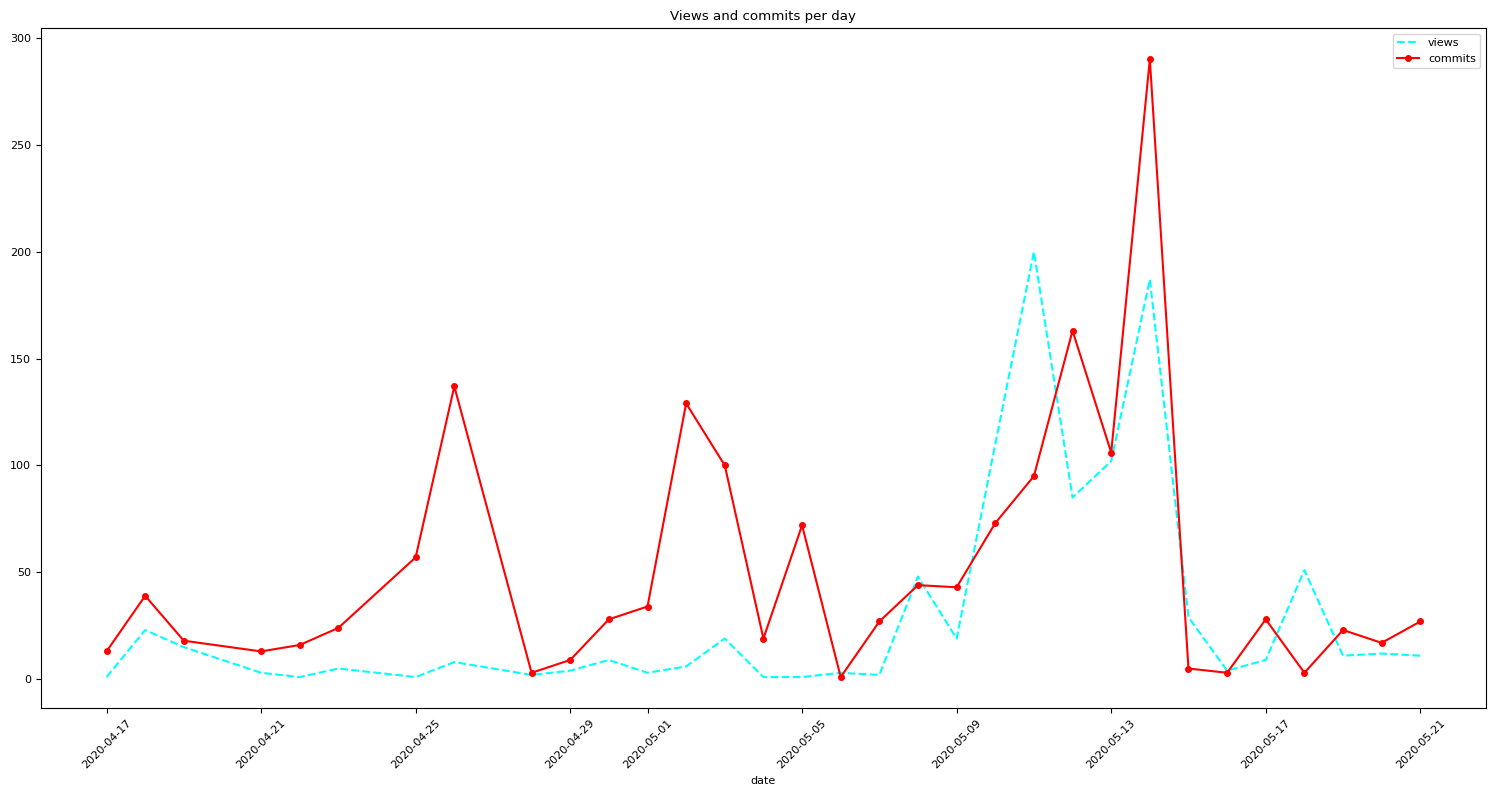

How many times was the number of views larger than 150? The answer is 2


In [4]:
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 8
fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(combined.index, combined['views'],
        color='cyan', linestyle='--', label='views')
ax.plot(combined.index, combined['commits'],
        color='red', marker='o', markersize=4, label='commits')

ax.set_title('Views and commits per day')
ax.set_xlabel('date')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Answer the question
answer = (combined['views'] > 150).sum()
print(f'How many times was the number of views larger than 150? The answer is {answer}')

How many times was the number of views larger than 150? The answer is ____.